<a href="https://colab.research.google.com/github/olumayowaadeniyi68-arch/MACHINE-LEARNING-EXERCISES/blob/main/Assignment_4_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup and Data Loading

First, let's import the necessary libraries, define data transformations, and load the MNIST dataset. We'll use `torchvision` for datasets and models, and `torch` for core PyTorch functionalities.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Check if GPU is available and set the device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Data Transformations and Loading

MNIST images are grayscale, but pre-trained CNNs like `resnet18` expect 3-channel RGB images. We'll transform the images to have 3 channels and normalize them.

In [ ]:
# Define transformations for the MNIST dataset
# Resize to 224x224 (expected by many pre-trained models)
# Convert to Tensor
# Normalize with ImageNet mean and std dev (as the pre-trained model was trained on ImageNet)
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(num_output_channels=3), # Convert to 3 channels
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Download and load the MNIST training data
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Download and load the MNIST test data
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.08MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.16MB/s]

Number of training samples: 60000
Number of test samples: 10000


## Model Definition

Now, let's load a pre-trained `resnet18` model from `torchvision` and modify its final fully connected layer to output 10 classes (for digits 0-9).

In [ ]:
import torchvision.models as models

# Load a pre-trained ResNet-18 model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all parameters in the network (optional, but good for fine-tuning)
# for param in model.parameters():
#     param.requires_grad = False

# Get the number of features in the last fully connected layer
num_ftrs = model.fc.in_features

# Replace the last layer with a new one for 10 classes (MNIST digits)
model.fc = nn.Linear(num_ftrs, 10)

# Move the model to the specified device (GPU or CPU)
model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Training and Evaluation Functions

We'll define functions for training one epoch and evaluating the model on the test set.

In [ ]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training function
def train(model, device, train_loader, optimizer, criterion):
    model.train() # Set the model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

    avg_loss = running_loss / len(train_loader)
    accuracy = 100 * correct / total
    print(f'Train Loss: {avg_loss:.4f}, Train Accuracy: {accuracy:.2f}%')
    return avg_loss, accuracy

# Evaluation function
def evaluate(model, device, test_loader, criterion):
    model.eval() # Set the model to evaluation mode
    test_loss = 0
    correct = 0
    with torch.no_grad(): # Disable gradient calculation during evaluation
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            test_loss += criterion(outputs, target).item() # Sum up batch loss
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == target).sum().item()

    test_loss /= len(test_loader)
    accuracy = 100. * correct / len(test_loader.dataset)
    print(f'\nTest Loss: {test_loss:.4f}, Test Accuracy: {accuracy:.2f}%\n')
    return test_loss, accuracy

## Fine-tuning the Model and Saving Weights

Now, let's fine-tune the model for a couple of epochs and save the trained weights.

In [ ]:
num_epochs = 2 # Fine-tune for 2 epochs as requested

for epoch in range(1, num_epochs + 1):
    print(f"Epoch {epoch}/{num_epochs}")
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)

# Save the model weights
model_save_path = 'mnist_resnet18_finetuned.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

Epoch 1/2
Train Loss: 0.0681, Train Accuracy: 97.92%

Test Loss: 0.0280, Test Accuracy: 99.06%

Epoch 2/2
Train Loss: 0.0354, Train Accuracy: 98.90%

Test Loss: 0.0328, Test Accuracy: 99.06%

Model weights saved to mnist_resnet18_finetuned.pth


## Gradio Interface for Deployment

To deploy the model on Hugging Face Spaces with Gradio, we need to create an `app.py` file. This file will contain the code to load our trained model, preprocess images, make predictions, and define the Gradio interface. We'll also include some example images for the Gradio interface.

In [ ]:
import gradio as gr
import numpy as np
from PIL import Image

# Ensure the model is loaded on the correct device for inference
model.eval() # Set to evaluation mode

# Define the prediction function for Gradio
def predict_image(image):
    # Convert Gradio image (numpy array) to PIL Image
    pil_image = Image.fromarray(image)

    # Apply the same transformations used during training
    input_tensor = transform(pil_image).unsqueeze(0).to(device) # Add batch dimension and move to device

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]

    # Return a dictionary of probabilities for each digit
    return {str(i): prob.item() for i, prob in enumerate(probabilities)}

# Interface setup
# Removed example_images for now due to file path errors
iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(width=224, height=224, image_mode='L', type='numpy'),
    outputs=gr.Label(num_top_classes=10),
    live=True,
    title="Fine-tuned ResNet-18 for MNIST",
    description="Upload a grayscale image of a digit (0-9) to get the predicted probabilities."
)

# To run the Gradio interface locally, uncomment the following line:
# iface.launch(debug=True)

print("Gradio interface created. To deploy on Hugging Face Spaces, you will need to save this code into an 'app.py' file.")

Gradio interface created. To deploy on Hugging Face Spaces, you will need to save this code into an 'app.py' file.


### Deployment on Hugging Face Spaces

To deploy this application on Hugging Face Spaces, follow these steps:

1.  **Create a new Space:** Go to [Hugging Face Spaces](https://huggingface.co/spaces) and create a new Space. Choose 'Gradio' as the SDK.
2.  **Clone the repository:** Clone your newly created Space's Git repository to your local machine.
3.  **Save your model weights:** Copy the `mnist_resnet18_finetuned.pth` file (generated earlier) into the root directory of your Space's repository.
4.  **Create `app.py`:** Create a file named `app.py` in the root directory of your Space's repository and paste the Gradio interface code from the previous cell into it.
5.  **Create `requirements.txt`:** Create a `requirements.txt` file in the root directory and add the necessary libraries:
    ```
    torch
    torchvision
    gradio
    Pillow
    ```
6.  **Add example images (optional but recommended):** If you want to use the example images as defined in the `app.py`, you'll need to create the `data/MNIST/raw/train-images-idx3-ubyte/` directory structure within your Space's repository and place corresponding grayscale images there. For simpler deployment, you can remove the `example_images` part from `app.py` or provide examples directly from common image URLs or base64 strings.
7.  **Commit and push:** Commit these files to your Space's Git repository and push them. Hugging Face Spaces will automatically build and deploy your Gradio app.

Your application should then be live and accessible through your Hugging Face Space URL!

## Creating `app.py` and `requirements.txt` for Download

Here are the commands to create `app.py` and `requirements.txt` directly in your Colab environment. Once these cells are executed, you'll see the files appear in the file browser (folder icon on the left sidebar), from where you can download them.

In [ ]:
app_py_content = """
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import gradio as gr
import numpy as np
from PIL import Image

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the pre-trained ResNet-18 model
model = models.resnet18(weights=None) # We don't need pre-trained weights for the architecture
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)
model.load_state_dict(torch.load('mnist_resnet18_finetuned.pth', map_location=device))
model = model.to(device)
model.eval() # Set the model to evaluation mode

# Define the transformations (must match training transformations)
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define the prediction function for Gradio
def predict_image(image):
    # Convert Gradio image (numpy array) to PIL Image
    pil_image = Image.fromarray(image)

    # Apply the same transformations used during training
    input_tensor = transform(pil_image).unsqueeze(0).to(device) # Add batch dimension and move to device

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]

    # Return a dictionary of probabilities for each digit
    return {str(i): prob.item() for i, prob in enumerate(probabilities)}

# Gradio Interface setup
iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(width=224, height=224, image_mode='L', type='numpy'),
    outputs=gr.Label(num_top_classes=10),
    live=True,
    title="Fine-tuned ResNet-18 for MNIST",
    description="Upload a grayscale image of a digit (0-9) to get the predicted probabilities."
)

# Launch the Gradio app (only for local testing, not for Hugging Face Spaces)
# iface.launch(debug=True)

if __name__ == '__main__':
    iface.launch(server_name="0.0.0.0", server_port=7860)
"""

with open('app.py', 'w') as f:
    f.write(app_py_content)

print("Created app.py")

Created app.py


In [ ]:
requirements_txt_content = """
torch
torchvision
gradio
Pillow
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_txt_content)

print("Created requirements.txt")

Created requirements.txt


### Important Note for Deployment:

When deploying to Hugging Face Spaces, remember to download the `mnist_resnet18_finetuned.pth` file (generated earlier in the notebook) and place it in the *same directory* as your `app.py` and `requirements.txt` files within your Space's repository. This file contains the trained model weights that `app.py` needs to load for making predictions.

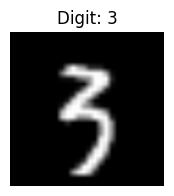

In [3]:
import matplotlib.pyplot as plt
import random
import torch
from torchvision import datasets, transforms

# Define transformations for the MNIST dataset (copied from earlier cell)
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Download and load the MNIST test data (copied from earlier cell)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Find indices of images that are '3' or '5'
indices_3_or_5 = [
    i for i, (img, label) in enumerate(test_dataset) if label == 3 or label == 5
]

# Pick a random index from the filtered list
if indices_3_or_5:
    random_index = random.choice(indices_3_or_5)
    image, label = test_dataset[random_index]

    # Convert the 3-channel image back to a format suitable for display (e.g., grayscale)
    # The image is normalized, so we need to reverse the normalization for proper display
    # The transform includes Grayscale(num_output_channels=3), ToTensor, Normalize

    # Un-normalize (using the mean and std dev defined earlier in 'transform')
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image_unnormalized = image * std + mean

    # Convert to numpy and then to grayscale (taking the first channel should be fine for display)
    image_display = image_unnormalized[0].cpu().numpy()

    plt.figure(figsize=(2,2))
    plt.imshow(image_display, cmap='gray', vmin=0, vmax=1) # Added vmin and vmax for better display
    plt.title(f"Digit: {label}")
    plt.axis('off')
    plt.show()
else:
    print("No images of '3' or '5' found in the test dataset.")

In [4]:
import matplotlib.pyplot as plt

# Define a filename for the image
image_filename = f"digit_{label}.png"

# Save the image to a file. Use `plt.imsave` for numpy arrays.
# Ensure the colormap and value range match the display for consistency.
plt.imsave(image_filename, image_display, cmap='gray', vmin=0, vmax=1)

print(f"Image saved as {image_filename}")
print("You can find and download this file from the file browser (folder icon on the left sidebar).")

Image saved as digit_3.png
You can find and download this file from the file browser (folder icon on the left sidebar).
